# Module B Report

This report documents the cab-sharing backend design and optimisation work: schema structure, security controls, index design, and measured performance impact.

The analysis addresses SubTask 4 (SQL Indexing and Query Optimisation) and SubTask 5 (Performance Benchmarking).

## Assignment Coverage Checklist

- **Schema Design**: normalized core and transactional tables with integrity constraints
- **Security**: JWT validation, password hashing, RBAC, and ownership checks
- **Indexing Strategy**: index selection mapped to real `WHERE`/`JOIN`/`ORDER BY` patterns
- **Performance Benchmarking**: repeated before-vs-after latency comparison with plots
- **Execution Plan Evidence**: EXPLAIN-based plan interpretation for indexed query paths

## 0) Application Methodology and Functionality

This system is a campus ride-sharing platform with a map-first flow. Rides and bookings are anchored on start/end geohashes, so discovery, selection, and route preview remain location-consistent across the product.

### System Methodology

The backend enforces the ride lifecycle and all critical constraints:
1. Host creates ride (`Open`/`Full` based on seat state).
2. Passenger submits booking (`Pending`).
3. Host accepts/rejects pending bookings.
4. Ride transitions `Started` -> `Completed`.
5. Settlements are generated and tracked.

The frontend focuses on usability (map picking, route previews, location suggestions), while validation remains server-side (capacity checks, role checks, duplicate booking prevention, status guards, settlement permissions).

### Observability Model

- API write actions are logged as structured audit entries.
- Database trigger logs classify writes as API-authorized vs direct DB modifications.
- Admin screens expose summary and detailed audit views for monitoring.

### Functional Coverage (Page-wise)

- **Home**: entry point into booking/hosting flow.
- **Login/Register**: JWT-based authentication and role-aware app state.
- **Rides**: booking mode and hosting mode with geohash selection and route previews.
- **My Bookings**: booking status, deletion, host manage-ride shortcut, chat/review entry.
- **Manage Ride**: host controls for updates, pending booking decisions, and lifecycle actions.
- **Ride Chat**: WebSocket messaging for host and confirmed passengers.
- **Locations / Saved Locations**: searchable locations and user-specific saved addresses.
- **Profile / Preferences / Reviews / Settlements**: account and transactional self-service pages.
- **Admin**: member/role management, ride monitoring, table operations, API audit logs, and unauthorized DB-change monitoring.

### Design Characteristics

- Geohash-driven consistency for booking and hosting routes.
- End-to-end host and passenger workflow coverage.
- Role and ownership boundaries enforced on server-side paths.
- Auditability at both application and database layers.

## 1) Schema Design

### Core Data Model

The design separates entity tables and transactional tables:

- **Members**: user profile identity (email, name, gender, reputation)
- **Auth_Credentials**: authentication data (username, password hash, role)
- **Rides**: host, route, departure, capacity, fare, status
- **Bookings**: ride-passenger association and booking status
- **Ride_Participants**: participant roles in each ride
- **Reputation_Reviews**: reviewer-reviewee ratings per ride
- **Cost_Settlements**: payment records linked to bookings
- **Locations / Saved_Addresses / User_Preferences / Ride_Chat** for auxiliary features

### Integrity and Non-duplication

- Foreign keys link transactional records to source entities (no profile duplication in Bookings/Reviews).
- Unique constraints enforce business rules, for example one booking per passenger per ride and one review per reviewer-reviewee pair per ride.
- Status fields are modeled as enums to constrain invalid states.

This structure keeps write paths consistent while preserving query flexibility for API endpoints.

## 2) Security Model

### Session Validation

- Access tokens are JWTs carrying member identity (`sub`) and expiry (`exp`).
- Authentication dependencies decode and validate tokens before route logic runs.
- Invalid, expired, or non-resolvable tokens are rejected with HTTP 401.

### Password Security

- Passwords are stored as PBKDF2-HMAC-SHA256 hashes with salt and high iteration count.
- Verification uses constant-time comparison (`hmac.compare_digest`) to reduce timing leak risk.

### RBAC and Ownership Enforcement

- Admin-only paths are protected by `get_current_admin_credential`; non-admin users receive HTTP 403.
- Ride lifecycle and moderation actions (accept/reject bookings, start/end ride, host ride edits) are restricted to the ride host.
- Booking deletion is restricted to the passenger who created that booking (or admin where explicitly allowed).
- Review/comment mutation is ownership-gated: only the authoring member can modify or delete their own review/comment entry.
- Settlement updates are permission-checked so unrelated members cannot change another user’s payment state.
- Chat participation is restricted to authorized ride participants and host context.

### Data Leak Prevention

- Row-level ownership checks are applied using the authenticated member id, not user-provided ids.
- Role checks and ownership checks are enforced server-side even if the UI hides unauthorized actions.
- DB session context stores actor/request metadata to support traceability and audit reconciliation.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
if (BASE_DIR / 'profiling').exists():
    ROOT_DIR = BASE_DIR
    PROFILING_DIR = BASE_DIR / 'profiling'
elif BASE_DIR.name == 'profiling':
    ROOT_DIR = BASE_DIR.parent
    PROFILING_DIR = BASE_DIR
else:
    ROOT_DIR = BASE_DIR
    PROFILING_DIR = BASE_DIR

before_json = PROFILING_DIR / 'profiling_results_before.json'
after_json = PROFILING_DIR / 'profiling_results_after.json'
repeated_json = PROFILING_DIR / 'repeated_comparison.json'

print('Profiling directory (relative):', PROFILING_DIR.relative_to(ROOT_DIR) if PROFILING_DIR.is_relative_to(ROOT_DIR) else PROFILING_DIR.name)
print('Before JSON exists:', before_json.exists())
print('After JSON exists:', after_json.exists())
print('Repeated JSON exists:', repeated_json.exists())

Profiling directory (relative): profiling
Before JSON exists: True
After JSON exists: True
Repeated JSON exists: True


## 3) Baseline Bottlenecks Before Indexing

Index design was based on the slowest baseline endpoints, ranked by repeated-run `before_avg_mean` latency.

This baseline ranking identifies which query paths needed optimization first.

In [2]:
# Load repeated benchmark aggregate outputs (preferred for robust conclusions)
with open(repeated_json, 'r', encoding='utf-8') as f:
    repeated = json.load(f)

comparison_df = pd.DataFrame(repeated['comparison'])
# Top slow endpoints before indexing (descending baseline latency)
baseline_slowest_df = comparison_df.sort_values('before_avg_mean', ascending=False).reset_index(drop=True)
baseline_slowest_df[['endpoint', 'before_avg_mean']].head(12)

,endpoint,before_avg_mean
0,admin :: GET /api/v1/admin/members,2664.623024
1,auth :: POST /api/v1/auth/register,267.311010
2,auth :: POST /api/v1/auth/login,251.466324
3,admin :: GET /api/v1/admin/rides/open,222.317317
4,admin :: GET /api/v1/admin/rides/completed,216.024971
5,admin :: GET /api/v1/admin/rides/stats,92.581265
6,admin :: GET /api/v1/admin/audit-logs,32.073748
7,settlements :: GET /api/v1/settlements/my,24.893434
8,rides :: GET /api/v1/rides,21.858499
9,admin :: GET /api/v1/admin/rides/active,18.588023


### How baseline bottlenecks guided index selection

- Slow read endpoints with `WHERE Ride_Status` and `ORDER BY Departure_Time` motivated `idx_rides_status_departure_time` on `Rides`.
- Slow booking retrieval by passenger and by ride-status ordering motivated `idx_bookings_passenger_booked_at` and `idx_bookings_ride_status_booked_at` on `Bookings`.
- Slow review feed/member endpoints motivated reviewer/reviewee and ride-time composite indexes on `Reputation_Reviews`.
- Slow settlement retrieval with booking/ride joins motivated join-support indexes (`idx_rides_host_ride_id`, `idx_settlements_settlement_booking`).

This establishes a direct path from observed baseline latency hotspots to index column choices used for optimization.

## 3.1) Indexing Strategy (SubTask 4)

Indexes were selected from the baseline slow/high-frequency endpoint query shapes.

| Index | Target Query Pattern | Target Endpoints |
|---|---|---|
| `idx_rides_status_departure_time (Ride_Status, Departure_Time)` | `WHERE Ride_Status ... ORDER BY Departure_Time` | `/rides`, `/admin/rides/open`, `/admin/rides/completed`, `/admin/rides/active` |
| `idx_bookings_ride_status_booked_at (RideID, Booking_Status, Booked_At)` | `WHERE RideID AND Booking_Status ORDER BY Booked_At` | `/rides/{ride_id}/bookings/pending` |
| `idx_bookings_passenger_booked_at (Passenger_MemberID, Booked_At)` | `WHERE Passenger_MemberID ORDER BY Booked_At` | `/rides/my/bookings` |
| `idx_reviews_ride_created_at (RideID, Created_At)` | `WHERE RideID ORDER BY Created_At` | `/reviews/ride/{ride_id}` |
| `idx_reviews_reviewer_created_at (Reviewer_MemberID, Created_At)` | `WHERE Reviewer_MemberID ORDER BY Created_At` | `/reviews/my`, part of `/reviews/member/{member_id}` |
| `idx_reviews_reviewee_created_at (Reviewee_MemberID, Created_At)` | `WHERE Reviewee_MemberID ORDER BY Created_At` | part of `/reviews/member/{member_id}` |
| `idx_rides_host_ride_id (Host_MemberID, RideID)` | host side of join/filter | `/settlements/my` |
| `idx_settlements_settlement_booking (SettlementID, BookingID)` | settlement ordering + booking join support | `/settlements/my` and settlement paths |

SQL DDL is in `indexes_apply.sql`, and rollback is in `indexes_drop.sql`.

In [3]:
comparison_df = comparison_df.sort_values('improvement_pct', ascending=False).reset_index(drop=True)
comparison_df[['endpoint', 'before_avg_mean', 'after_avg_mean', 'delta_ms', 'improvement_pct']].head(15)

,endpoint,before_avg_mean,after_avg_mean,delta_ms,improvement_pct
0,admin :: GET /api/v1/admin/rides/active,18.588023,5.543652,13.044372,70.176218
1,rides :: GET /api/v1/rides,21.858499,14.428153,7.430346,33.992938
2,admin :: GET /api/v1/admin/rides/stats,92.581265,71.949992,20.631273,22.284501
3,locations :: GET /api/v1/locations/{location_id},5.016944,4.498744,0.518200,10.329004
4,admin :: GET /api/v1/admin/tables,7.205584,6.468782,0.736802,10.225425
5,admin :: GET /api/v1/admin/rides/{ride_id}/par...,7.992625,7.291565,0.701060,8.771340
6,settlements :: GET /api/v1/settlements/booking...,7.986891,7.309775,0.677116,8.477841
7,admin :: PATCH /api/v1/admin/tables/{table_nam...,14.593363,13.736641,0.856721,5.870624
8,rides :: DELETE /api/v1/rides/{ride_id},10.417752,9.845018,0.572734,5.497672
9,chat :: GET /api/v1/chat/ride/{ride_id},7.677765,7.262392,0.415373,5.410075


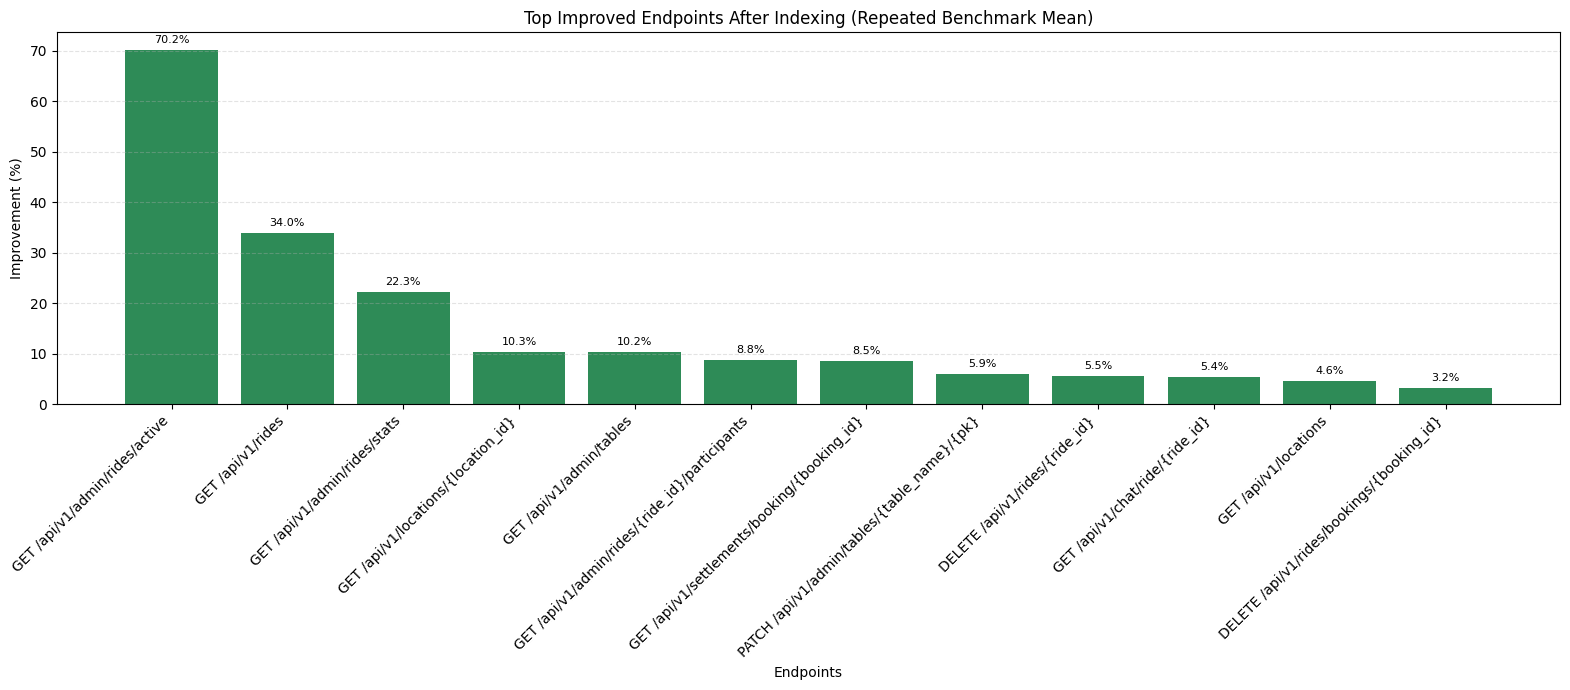

In [4]:
# Plot A: Top improved endpoints (vertical bar plot)
top_n = 12
top_df = comparison_df.head(top_n).copy()

plt.figure(figsize=(16, 7))
bars = plt.bar(range(len(top_df)), top_df['improvement_pct'], color='seagreen')
plt.xticks(range(len(top_df)), [e.split(' :: ')[-1] for e in top_df['endpoint']], rotation=45, ha='right')
plt.ylabel('Improvement (%)')
plt.xlabel('Endpoints')
plt.title('Top Improved Endpoints After Indexing (Repeated Benchmark Mean)')
plt.grid(axis='y', linestyle='--', alpha=0.35)

for bar, val in zip(bars, top_df['improvement_pct']):
    plt.annotate(f'{val:.1f}%', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                 textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

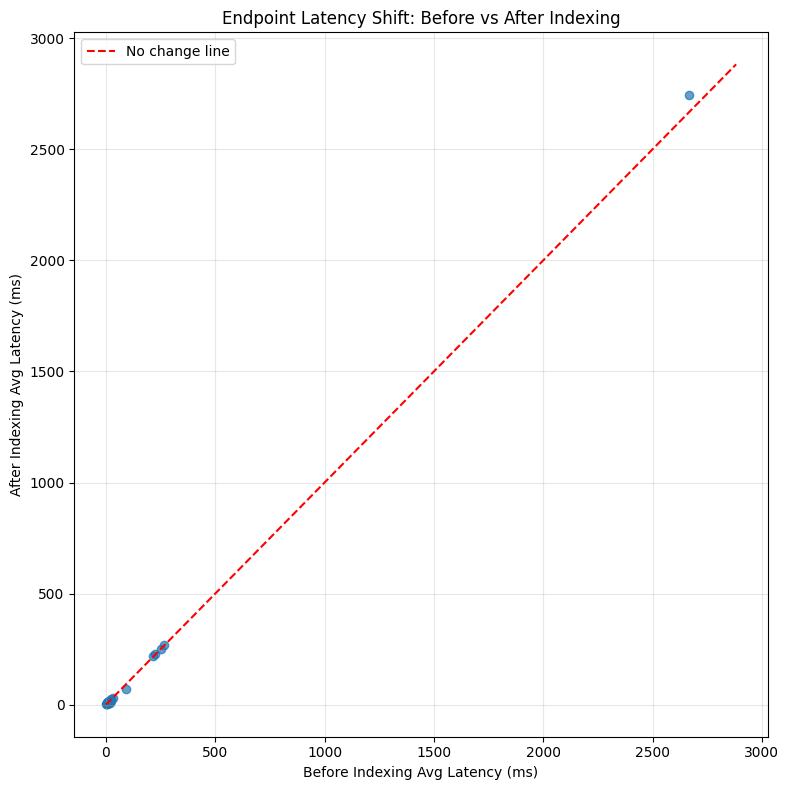

In [5]:
# Plot B: Before vs After average latency (all endpoints scatter)
plt.figure(figsize=(8, 8))
plt.scatter(comparison_df['before_avg_mean'], comparison_df['after_avg_mean'], alpha=0.7)

mx = max(comparison_df['before_avg_mean'].max(), comparison_df['after_avg_mean'].max()) * 1.05
plt.plot([0, mx], [0, mx], linestyle='--', color='red', label='No change line')

plt.xlabel('Before Indexing Avg Latency (ms)')
plt.ylabel('After Indexing Avg Latency (ms)')
plt.title('Endpoint Latency Shift: Before vs After Indexing')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

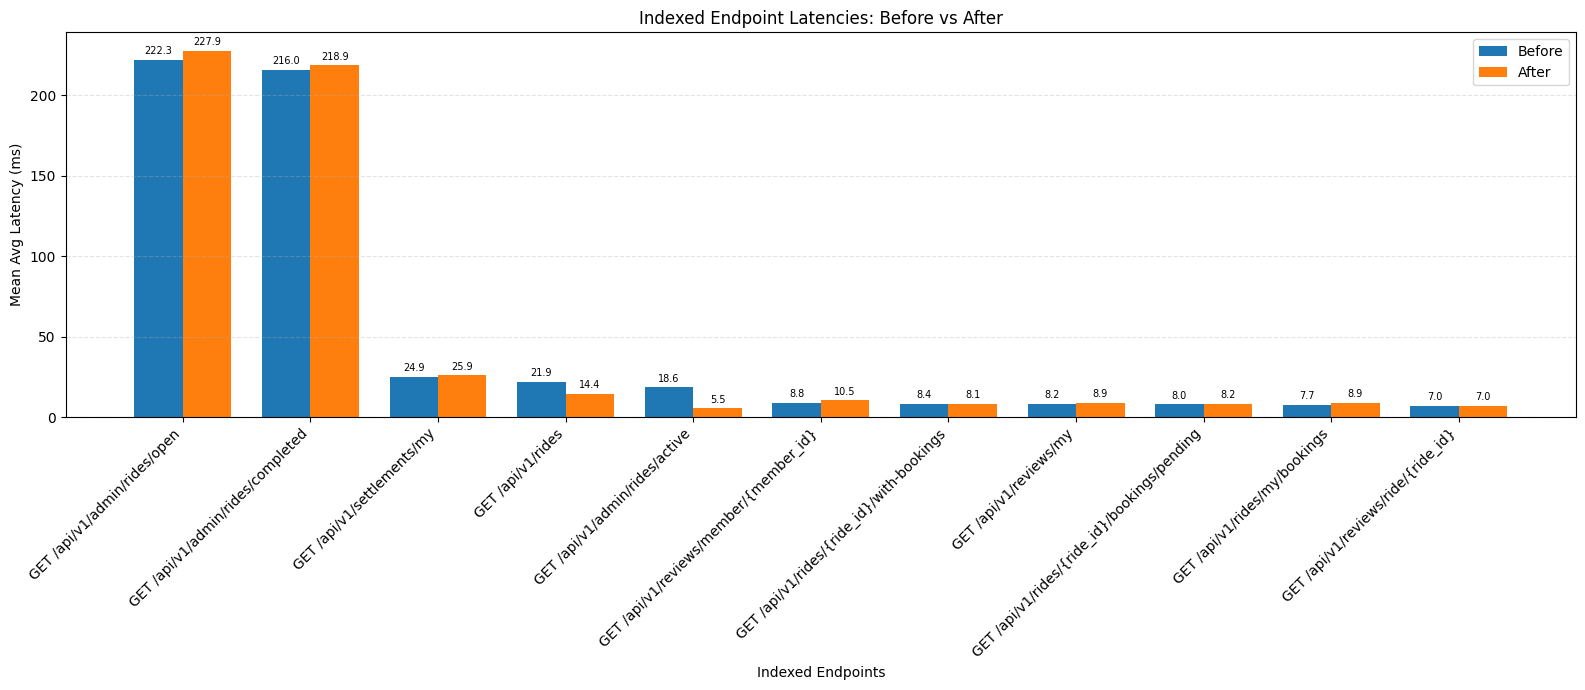

In [6]:
# Plot C: Before vs After grouped bars for explicitly indexed endpoints
target_keywords = [
    'GET /api/v1/rides',
    'GET /api/v1/admin/rides/open',
    'GET /api/v1/admin/rides/completed',
    'GET /api/v1/admin/rides/active',
    'GET /api/v1/rides/my/bookings',
    'GET /api/v1/rides/{ride_id}/bookings/pending',
    'GET /api/v1/reviews/ride/{ride_id}',
    'GET /api/v1/reviews/member/{member_id}',
    'GET /api/v1/reviews/my',
    'GET /api/v1/settlements/my',
]

sel = comparison_df[comparison_df['endpoint'].apply(lambda x: any(k in x for k in target_keywords))].copy()
sel = sel.sort_values('before_avg_mean', ascending=False).reset_index(drop=True)

x = range(len(sel))
w = 0.38
plt.figure(figsize=(16, 7))
b1 = plt.bar([i - w/2 for i in x], sel['before_avg_mean'], width=w, label='Before')
b2 = plt.bar([i + w/2 for i in x], sel['after_avg_mean'], width=w, label='After')

plt.xticks(list(x), [e.split(' :: ')[-1] for e in sel['endpoint']], rotation=45, ha='right')
plt.ylabel('Mean Avg Latency (ms)')
plt.xlabel('Indexed Endpoints')
plt.title('Indexed Endpoint Latencies: Before vs After')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.35)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        plt.annotate(f'{h:.1f}', (bar.get_x()+bar.get_width()/2, h), textcoords='offset points', xytext=(0, 4), ha='center', fontsize=7)

plt.tight_layout()
plt.show()

## 3.2 Analysis of Mixed Latency Results

Repeated runs show both improvements and regressions after indexing.

- **Clear improvements** appear where query shape aligns with index prefix and sort order (for example `Rides` by `Ride_Status` and `Departure_Time`).
- **Regressions** mostly come from four causes:
  1. **Low-selectivity predicates** that still touch many rows.
  2. **OR predicates across columns/tables** that trigger `index_merge` and `filesort`.
  3. **Write-side index maintenance overhead** on insert/update/delete paths.
  4. **Large response payloads** on broad reads (for example `/admin/members`), where serialization and transfer cost dominate latency.

### EXPLAIN-aligned observations

- `Rides` list/open/completed uses `idx_rides_status_departure_time` with index condition or backward index scan, consistent with better read performance for targeted routes.
- `Bookings` by passenger uses `idx_bookings_passenger_booked_at` with backward index scan, showing index-aligned retrieval.
- `Reputation_Reviews` member feed shows `index_merge + filesort` for OR predicates, which explains weaker or negative gains.
- `Settlements /my` remains sensitive to driving scan order and post-join filtering, so gains are smaller or unstable.
- `Admin /members` remains one of the slowest APIs mainly due to large row return size, not only index access path.

### Section conclusion

Indexing materially improves targeted retrieval paths, but results are endpoint-specific. The most reliable interpretation combines repeated latency measurements with EXPLAIN plan behavior.

## 4) Exact SQL Statements (Before vs After)

For indexed endpoints, the application SQL text stays logically the same before and after indexing.

### Example endpoint SQL

- **GET /api/v1/rides**
```sql
SELECT * FROM Rides
WHERE Ride_Status = 'Open'
ORDER BY Departure_Time ASC
LIMIT :limit;
```

- **GET /api/v1/rides/{ride_id}/bookings/pending**
```sql
SELECT * FROM Bookings
WHERE RideID = :ride_id AND Booking_Status = 'Pending'
ORDER BY Booked_At DESC;
```

- **GET /api/v1/settlements/my**
```sql
SELECT cs.*
FROM Cost_Settlements cs
JOIN Bookings b ON b.BookingID = cs.BookingID
JOIN Rides r ON r.RideID = b.RideID
WHERE b.Passenger_MemberID = :member_id OR r.Host_MemberID = :member_id
ORDER BY cs.SettlementID DESC;
```

The measurable change is in the execution plan (`EXPLAIN`) and resulting latency, not query text itself.

In [7]:
# EXPLAIN evidence queries (requires mysql CLI and permissions)
from pathlib import Path
import os
import subprocess

def load_env(env_path: Path) -> dict[str, str]:
    values = {}
    if not env_path.exists():
        return values
    for raw_line in env_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values

base_dir = Path.cwd()
root_dir = base_dir.parent if base_dir.name == 'profiling' else base_dir
env_values = load_env(root_dir / 'backend' / '.env')

mysql_user = env_values.get('MYSQL_USER', 'root')
mysql_password = env_values.get('MYSQL_PASSWORD', '')
mysql_db = 'cabSharing'

explain_queries = [
    "EXPLAIN SELECT * FROM Rides WHERE Ride_Status = 'Open' ORDER BY Departure_Time ASC LIMIT 100;",
    "EXPLAIN SELECT * FROM Rides WHERE Ride_Status = 'Completed' ORDER BY Departure_Time DESC;",
    "EXPLAIN SELECT * FROM Bookings WHERE Passenger_MemberID = 20027 ORDER BY Booked_At DESC;",
    "EXPLAIN SELECT * FROM Reputation_Reviews WHERE Reviewer_MemberID = 20027 OR Reviewee_MemberID = 20027 ORDER BY Created_At DESC;",
    "EXPLAIN SELECT cs.* FROM Cost_Settlements cs JOIN Bookings b ON b.BookingID = cs.BookingID JOIN Rides r ON r.RideID = b.RideID WHERE b.Passenger_MemberID = 20027 OR r.Host_MemberID = 20027 ORDER BY cs.SettlementID DESC;",
]

mysql_env = os.environ.copy()
if mysql_password:
    mysql_env['MYSQL_PWD'] = mysql_password

for q in explain_queries:
    cmd = ['mysql', f'-u{mysql_user}', mysql_db, '-e', q]
    print('\n---', q)
    out = subprocess.run(cmd, capture_output=True, text=True, env=mysql_env)
    print(out.stdout if out.returncode == 0 else out.stderr)


--- EXPLAIN SELECT * FROM Rides WHERE Ride_Status = 'Open' ORDER BY Departure_Time ASC LIMIT 100;
id	select_type	table	partitions	type	possible_keys	key	key_len	ref	rows	filtered	Extra
1	SIMPLE	Rides	NULL	ref	idx_rides_status_departure_time	idx_rides_status_departure_time	1	const	5106	100.00	Using index condition


--- EXPLAIN SELECT * FROM Rides WHERE Ride_Status = 'Completed' ORDER BY Departure_Time DESC;
id	select_type	table	partitions	type	possible_keys	key	key_len	ref	rows	filtered	Extra
1	SIMPLE	Rides	NULL	ref	idx_rides_status_departure_time	idx_rides_status_departure_time	1	const	5082	100.00	Using where; Backward index scan


--- EXPLAIN SELECT * FROM Bookings WHERE Passenger_MemberID = 20027 ORDER BY Booked_At DESC;
id	select_type	table	partitions	type	possible_keys	key	key_len	ref	rows	filtered	Extra
1	SIMPLE	Bookings	NULL	ref	Passenger_MemberID,idx_bookings_passenger_booked_at	idx_bookings_passenger_booked_at	4	const	207	100.00	Backward index scan


--- EXPLAIN SELECT * FROM

## 4.1 EXPLAIN Evidence and Interpretation

The table below summarizes observed EXPLAIN output for member `20027`.

| Query | Access Pattern (Observed) | Interpretation |
|---|---|---|
| `Rides` open ordered by departure | `type=ref`, key `idx_rides_status_departure_time`, rows `5106`, `Using index condition` | Composite index supports status filtering and ordered retrieval, matching read-path gains. |
| `Rides` completed ordered descending | `type=ref`, same key, rows `5082`, `Backward index scan` | Reverse index traversal avoids full sort and improves completed-ride listing behavior. |
| `Bookings` by passenger ordered by booked time | `type=ref`, key `idx_bookings_passenger_booked_at`, rows `207`, `Backward index scan` | Selective lookup plus order alignment yields efficient retrieval. |
| `Reputation_Reviews` member query with OR | `type=index_merge`, keys `Reviewer_MemberID` + `Reviewee_MemberID`, rows `21`, `Using union(...); Using where; Using filesort` | OR across two columns causes merge/filesort, so index benefit is partial. |
| `Settlements /my` join with passenger-or-host filter | `cs` read by `PRIMARY` index order (`rows=7582`, `Backward index scan`), `b` and `r` by `eq_ref`, `Using where` on `r` | Join probes are efficient, but driving scan plus late filtering limits total gain. |

### Why outcomes remain mixed

1. **Aligned read filters improve** when index prefixes match `WHERE` + `ORDER BY`.
2. **OR-heavy query shapes remain expensive** due to `index_merge`, filesort, and post-join filtering.
3. **Indexing is not universally beneficial**; some query paths still perform substantial scan/filter work.

### Final interpretation

The optimization succeeds for the intended indexed access paths, but impact varies by endpoint and query shape.

## 5) Performance Benchmarking Conclusions (SubTask 5)

- Repeated before/after runs reduce variance and support stable endpoint-level comparison.
- Quantitative comparison uses endpoint means and standard deviations from `repeated_comparison.json`.
- EXPLAIN confirms optimizer behavior changes on targeted indexed reads (`ref` access and backward index scans).
- Mixed outcomes are expected: read paths aligned with index structure improve, while OR-heavy queries, broad payload endpoints, and some write paths can stay flat or regress slightly.

Overall, indexing delivers clear gains on the intended query patterns, with endpoint-specific trade-offs visible in both latency metrics and execution plans.